# A Load data

In [16]:
#  1 immports
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loading import *
from src.preprocessing import *
from src.train import *
from src.visualization import *
from src.evaluate import evaluate_model
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import glob
import json
import pandas as pd
from src.preprocessing import build_dataset
from src.data_loading import get_data_splits, save_splits
import os
from src.preprocessing import build_dataset
from src.visualization import plot_confusion_matrix
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [2]:
#  2: Load config and data
config = load_config('../configs/config.yaml')
data_dir = config['data']['data_dir']
s2_dir = os.path.join(data_dir, config['data']['s2_dir'])
ann_dir = os.path.join(data_dir, config['data']['ann_dir'])

# B EDA

In [3]:
# 1. Verify file counts
s2_files = sorted(glob.glob(os.path.join(s2_dir, 'S2_*.npy')))
ann_files = sorted(glob.glob(os.path.join(ann_dir, 'TARGET_*.npy')))

print("\n=== DATASET COUNT ===")
print(f"Total S2 patch files: {len(s2_files)}")
print(f"Total Annotation target files: {len(ann_files)}")


=== DATASET COUNT ===
Total S2 patch files: 102
Total Annotation target files: 102


In [4]:
# 2. Inspect raw array shapes and data types
sample_s2 = np.load(s2_files[0])
sample_ann = np.load(ann_files[0])

print("\n=== RAW ARRAY STRUCTURE ===")
print(f"S2 Shape (Dates, Bands, Height, Width): {sample_s2.shape}")
print(f"Target Shape (Layers, Height, Width):   {sample_ann.shape}")
print(f"S2 Value Range: Min = {sample_s2.min()}, Max = {sample_s2.max()}")
print(f"Target Value Range: Min = {sample_ann.min()}, Max = {sample_ann.max()}")


=== RAW ARRAY STRUCTURE ===
S2 Shape (Dates, Bands, Height, Width): (46, 10, 128, 128)
Target Shape (Layers, Height, Width):   (1, 128, 128)
S2 Value Range: Min = -105, Max = 14924
Target Value Range: Min = 0, Max = 19


In [5]:
# 3. Analyze Class Distribution across all annotation files
class_names = {
    0: 'Background', 1: 'Meadow', 2: 'Soft winter wheat', 3: 'Corn',
    4: 'Winter barley', 5: 'Winter rapeseed', 6: 'Spring barley', 7: 'Sunflower',
    8: 'Grapevine', 9: 'Beet', 10: 'Winter triticale', 11: 'Winter durum wheat',
    12: 'Fruits/veg/flowers', 13: 'Potatoes', 14: 'Leguminous fodder',
    15: 'Soybeans', 16: 'Orchard', 17: 'Mixed cereal', 18: 'Sorghum', 19: 'Void label'
}

raw_counts = {k: 0 for k in class_names.keys()}
for f in ann_files:
    target = np.load(f)[0]
    uniques, u_counts = np.unique(target, return_counts=True)
    for u, c in zip(uniques, u_counts):
        if u in raw_counts:
            raw_counts[u] += c

df_classes = pd.DataFrame([
    {'Class_ID': k, 'Class_Name': v, 'Total_Pixels': raw_counts[k]}
    for k, v in class_names.items()
])
df_classes['Percentage (%)'] = (df_classes['Total_Pixels'] / df_classes['Total_Pixels'].sum()) * 100

print("\n=== RAW CLASS DISTRIBUTION ===")
print(df_classes[df_classes['Total_Pixels'] > 0].to_string(index=False))



=== RAW CLASS DISTRIBUTION ===
 Class_ID         Class_Name  Total_Pixels  Percentage (%)
        0         Background        506141       30.286662
        1             Meadow        296576       17.746630
        2  Soft winter wheat        199108       11.914302
        3               Corn        196704       11.770450
        4      Winter barley         57381        3.433587
        5    Winter rapeseed         92912        5.559704
        6      Spring barley          3472        0.207759
        7          Sunflower          9579        0.573192
        8          Grapevine          1345        0.080483
       10   Winter triticale         15215        0.910441
       11 Winter durum wheat           725        0.043383
       12 Fruits/veg/flowers          3229        0.193218
       13           Potatoes           158        0.009454
       14  Leguminous fodder         12634        0.755998
       15           Soybeans        121560        7.273955
       16            Orc

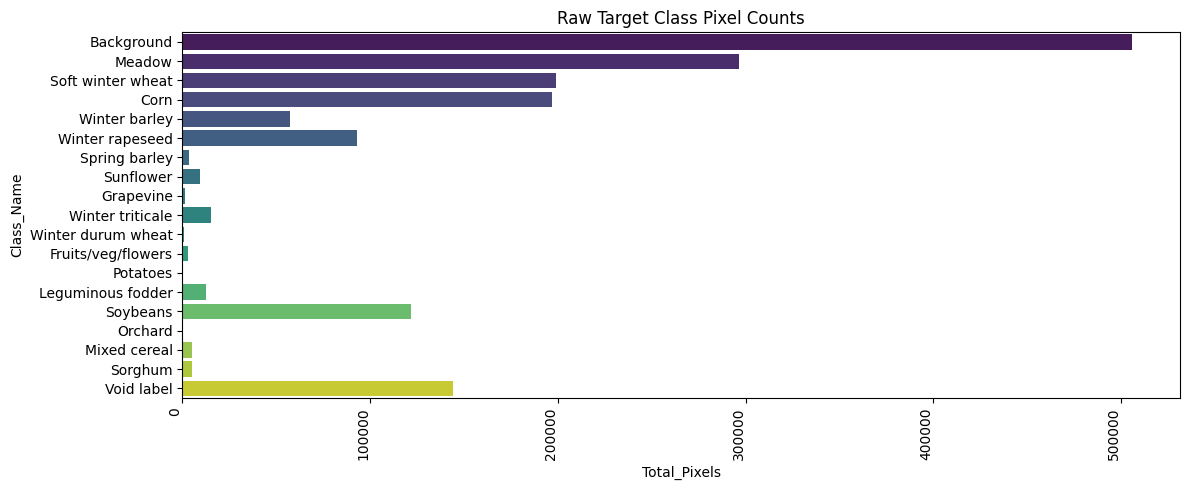

In [6]:

# Plot raw class distribution
plt.figure(figsize=(12, 5))
sns.barplot(data=df_classes[df_classes['Total_Pixels'] > 0], y='Class_Name', x='Total_Pixels', palette='viridis')
plt.xticks(rotation=90, ha='right')
plt.title('Raw Target Class Pixel Counts')
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/eda_raw_class_distribution.png')
plt.show()




=== METADATA INFO ===
Total metadata records: 102


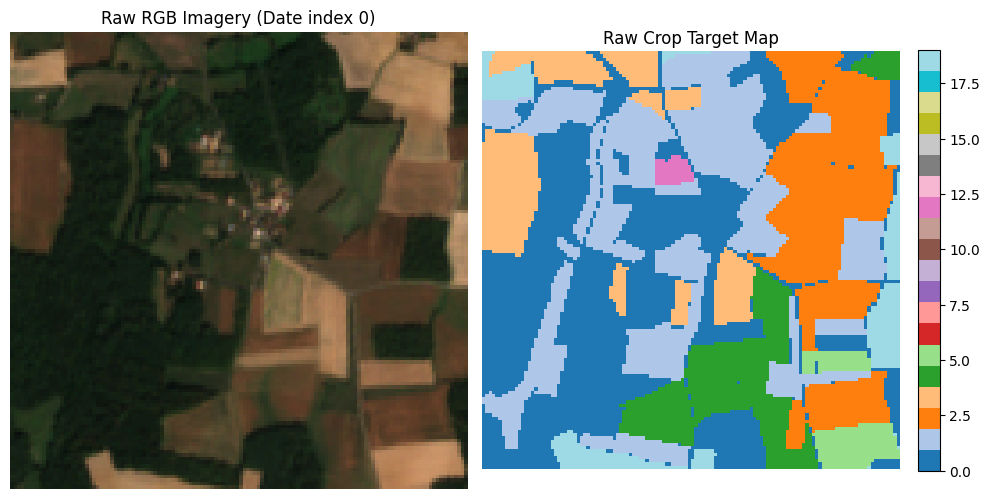

In [7]:
# 4. Read metadata dates and geographic extent
meta_path = os.path.join(data_dir, 'metadata.geojson')
if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    print("\n=== METADATA INFO ===")
    print(f"Total metadata records: {len(meta['features'])}")

# 5. Visual inspection of a raw sample patch
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Extract RGB (B4=Red, B3=Green, B2=Blue) at timestamp 0
rgb = sample_s2[0, [2, 1, 0], :, :].transpose(1, 2, 0)
# Scale display brightness without altering underlying dataset
rgb_display = np.clip(rgb / 3000.0, 0, 1)

ax[0].imshow(rgb_display)
ax[0].set_title("Raw RGB Imagery (Date index 0)")
ax[0].axis("off")

im = ax[1].imshow(sample_ann[0], cmap='tab20', vmin=0, vmax=19)
ax[1].set_title("Raw Crop Target Map")
ax[1].axis("off")

plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_raw_patch_sample.png')
plt.show()

In [8]:
#5 Extraction of AOI Geographic Extent

meta_path = os.path.join(data_dir, 'metadata.geojson')

if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    
    lons, lats = [], []
    for feature in meta['features']:
        coords = feature['geometry']['coordinates']
        flat_coords = np.array(coords).reshape(-1, 2)
        lons.extend(flat_coords[:, 0])
        lats.extend(flat_coords[:, 1])
        
    min_lon, max_lon = np.min(lons), np.max(lons)
    min_lat, max_lat = np.min(lats), np.max(lats)
    
    print("=== AOI GEOGRAPHIC EXTENT ===")
    print(f"Longitude Bounding Box: [{min_lon:.5f}, {max_lon:.5f}]")
    print(f"Latitude Bounding Box:  [{min_lat:.5f}, {max_lat:.5f}]")
    print(f"Spatial Center Point:   [{(min_lon + max_lon)/2:.5f}, {(min_lat + max_lat)/2:.5f}]")
else:
    print("metadata.geojson not found in the root data directory.")

=== AOI GEOGRAPHIC EXTENT ===
Longitude Bounding Box: [848543.86576, 881795.53337]
Latitude Bounding Box:  [6613305.27195, 6649116.85686]
Spatial Center Point:   [865169.69956, 6631211.06441]


# C. Train / Validation / Test Split

In [9]:
# 1. Execute patch-level dataset partition using s2_dir
train_ids, val_ids, test_ids = get_data_splits(s2_dir)

# 2. Save split patch IDs to text files for reproducibility
save_splits(train_ids, val_ids, test_ids)

# 3. Display split allocation table
total_patches = len(train_ids) + len(val_ids) + len(test_ids)

split_summary = pd.DataFrame([
    {'Split': 'Train', 'Patch Count': len(train_ids), 'Percentage': f"{(len(train_ids)/total_patches)*100:.2f}%"},
    {'Split': 'Validation', 'Patch Count': len(val_ids), 'Percentage': f"{(len(val_ids)/total_patches)*100:.2f}%"},
    {'Split': 'Test', 'Patch Count': len(test_ids), 'Percentage': f"{(len(test_ids)/total_patches)*100:.2f}%"},
    {'Split': 'Total', 'Patch Count': total_patches, 'Percentage': '100.00%'}
])

print("=== PART C: DATASET SPLIT SUMMARY ===")
print(split_summary.to_string(index=False))

=== PART C: DATASET SPLIT SUMMARY ===
     Split  Patch Count Percentage
     Train           71     69.61%
Validation           15     14.71%
      Test           16     15.69%
     Total          102    100.00%


In [10]:
# 4. Verify spatial independence (disjoint sets)
train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)
assert len(train_set.intersection(val_set)) == 0, "Data leakage detected between Train and Validation sets."
assert len(train_set.intersection(test_set)) == 0, "Data leakage detected between Train and Test sets."
assert len(val_set.intersection(test_set)) == 0, "Data leakage detected between Validation and Test sets."

print("\nData Leakage Check: PASSED (Disjoint partitions verified)")
print(f"Train Patch IDs (sample): {train_ids[:5]}")
print(f"Val Patch IDs   (sample): {val_ids[:5]}")
print(f"Test Patch IDs  (sample): {test_ids[:5]}")


Data Leakage Check: PASSED (Disjoint partitions verified)
Train Patch IDs (sample): ['30066', '30732', '30361', '30178', '30418']
Val Patch IDs   (sample): ['30436', '30410', '30694', '30297', '30335']
Test Patch IDs  (sample): ['30495', '30026', '30438', '30209', '30062']


# D model training

In [11]:
# 1. Construct training feature matrix and targets (with pixel sampling)
X_train, y_train = build_dataset(
    train_ids, s2_dir, ann_dir,
    max_patches=config['sampling']['max_patches'],
    pixels_per_patch=config['sampling']['pixels_per_patch']
)

# 2. Construct validation feature matrix and targets (all valid pixels)
X_val, y_val = build_dataset(val_ids, s2_dir, ann_dir)

print("=== PART D: DATA PREPARATION ===")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}   | y_val shape:   {y_val.shape}")

=== PART D: DATA PREPARATION ===
X_train shape: (30000, 40) | y_train shape: (30000,)
X_val shape:   (160243, 40)   | y_val shape:   (160243,)


In [12]:
# Verify target classes
unique_train_classes = np.unique(y_train)
print(f"Training target classes present: {sorted(unique_train_classes)}")

Training target classes present: [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(10), np.uint8(12), np.uint8(14), np.uint8(15), np.uint8(17), np.uint8(18)]


In [13]:
# 3. Train LightGBM classifier
print("\n=== PART D: MODEL TRAINING ===")
model = train_model(X_train, y_train, config)


=== PART D: MODEL TRAINING ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 40
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start traini

In [14]:
# 4. Serialize trained model weights
model_dir = "../outputs/models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "lightgbm_model.pkl")
save_model(model, model_path)

print(f"Model successfully trained and saved to: {model_path}")

Model successfully trained and saved to: ../outputs/models\lightgbm_model.pkl


# E Model evaluation

In [17]:
# 1. Build test dataset from holdout test patch IDs
X_test, y_test = build_dataset(test_ids, s2_dir, ann_dir)

# 2. Evaluate model on Validation set
val_metrics_dir = os.path.join('..', 'outputs', 'metrics', 'val')
y_val_pred, val_acc, val_report, val_cm = evaluate_model(
    model, X_val, y_val, save_dir=val_metrics_dir
)

# 3. Evaluate model on Test set
test_metrics_dir = os.path.join('..', 'outputs', 'metrics', 'test')
y_test_pred, test_acc, test_report, test_cm = evaluate_model(
    model, X_test, y_test, save_dir=test_metrics_dir
)

# 4. Compute per-class IoU and mIoU (Mean Intersection over Union)
def calculate_miou(cm):
    """
    Computes Intersection over Union (IoU) per class and Mean IoU (mIoU)
    from a multi-class confusion matrix.
    IoU_c = TP_c / (TP_c + FP_c + FN_c)
    """
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    
    denominator = tp + fp + fn
    # Avoid division by zero for unrepresented classes in ground truth/predictions
    valid_mask = denominator > 0
    
    iou_per_class = np.zeros_like(tp, dtype=float)
    iou_per_class[valid_mask] = tp[valid_mask] / denominator[valid_mask]
    
    mean_iou = np.mean(iou_per_class[valid_mask])
    return iou_per_class, mean_iou, valid_mask

test_iou_per_class, test_miou, valid_mask = calculate_miou(test_cm)

# 5. Display Evaluation Results Summary
print("=== PART E: EVALUATION RESULTS SUMMARY ===")
print(f"Validation Overall Accuracy: {val_acc:.4f}")
print(f"Test Overall Accuracy:       {test_acc:.4f}")
print(f"Test Mean IoU (mIoU):        {test_miou:.4f}")

=== PART E: EVALUATION RESULTS SUMMARY ===
Validation Overall Accuracy: 0.5993
Test Overall Accuracy:       0.5679
Test Mean IoU (mIoU):        0.1744


In [19]:
# Map present class IDs to names
class_names = {
    1: 'Meadow', 2: 'Soft winter wheat', 3: 'Corn', 4: 'Winter barley',
    5: 'Winter rapeseed', 6: 'Spring barley', 7: 'Sunflower', 8: 'Grapevine',
    9: 'Beet', 10: 'Winter triticale', 11: 'Winter durum wheat',
    12: 'Fruits/veg/flowers', 13: 'Potatoes', 14: 'Leguminous fodder',
    15: 'Soybeans', 16: 'Orchard', 17: 'Mixed cereal', 18: 'Sorghum'
}

test_present_classes = sorted(np.unique(y_test))

df_metrics = pd.DataFrame([
    {
        'Class ID': cls_id,
        'Class Name': class_names.get(cls_id, f'Class {cls_id}'),
        'Precision': test_report[str(cls_id)]['precision'],
        'Recall': test_report[str(cls_id)]['recall'],
        'F1-Score': test_report[str(cls_id)]['f1-score'],
        'IoU': iou,
        'Support': test_report[str(cls_id)]['support']
    }
    for cls_id, iou in zip(test_present_classes, test_iou_per_class[valid_mask])
])

print("\n=== PER-CLASS TEST PERFORMANCE METRICS ===")
print(df_metrics.to_string(index=False))


=== PER-CLASS TEST PERFORMANCE METRICS ===
 Class ID         Class Name  Precision   Recall  F1-Score      IoU  Support
        1             Meadow   0.739726 0.905710  0.814346 0.686833  43483.0
        2  Soft winter wheat   0.542606 0.524612  0.533457 0.363752  31692.0
        3               Corn   0.311677 0.463036  0.372571 0.228932  23374.0
        4      Winter barley   0.471248 0.079785  0.136465 0.073229  12634.0
        5    Winter rapeseed   0.842419 0.790453  0.815609 0.688632  10537.0
        6      Spring barley   0.000000 0.000000  0.000000 0.000000   1345.0
        7          Sunflower   0.000000 0.000000  0.000000 0.000000   2618.0
       10   Winter triticale   0.172338 0.035528  0.058912 0.000000   4419.0
       12 Fruits/veg/flowers   0.000000 0.000000  0.000000 0.030350    174.0
       14  Leguminous fodder   0.046512 0.006729  0.011758 0.000000   1486.0
       15           Soybeans   0.499921 0.527505  0.513343 0.005914  18106.0
       17       Mixed cereal   0

In [22]:
# 6. Plot and export Test Confusion Matrix
fig_dir = os.path.join('..', 'outputs', 'figures')
os.makedirs(fig_dir, exist_ok=True)
test_labels = [class_names.get(c, f'Class {c}') for c in test_present_classes]
plot_confusion_matrix(test_cm, test_labels, os.path.join(fig_dir, 'test_confusion_matrix.png'))

print(f"\nArtifacts saved to:\n - Metrics: {os.path.abspath(test_metrics_dir)}\n - Figure:  {os.path.abspath(os.path.join(fig_dir, 'test_confusion_matrix.png'))}")



Artifacts saved to:
 - Metrics: C:\Users\user\Documents\freelance\independent_projects\agri_assign_sola\Agri-Assignment_01\sentinel2-crop-classification\outputs\metrics\test
 - Figure:  C:\Users\user\Documents\freelance\independent_projects\agri_assign_sola\Agri-Assignment_01\sentinel2-crop-classification\outputs\figures\test_confusion_matrix.png


# F Visualization

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from src.data_loading import load_patch
from src.preprocessing import prepare_data
from src.visualization import apply_spatial_smoothing, plot_prediction_comparison

# 1. Select target patch from test_ids
test_patch_id = test_ids[0]

# 2. Load satellite patch and ground-truth annotation
s2_patch, target_patch = load_patch(test_patch_id, s2_dir, ann_dir)

# 3. Construct True Color RGB Composite (Bands B4=Index 2, B3=Index 1, B2=Index 0)
rgb = s2_patch[0, [2, 1, 0], :, :].transpose(1, 2, 0)
rgb = np.clip(rgb / 3000.0, 0, 1)

# 4. Generate tabular feature matrix and inference mask
X_patch, _, valid_mask = prepare_data(s2_patch, target_patch)
patch_preds = model.predict(X_patch)

# 5. Reconstruct 2D spatial prediction raster
pred_map = np.zeros_like(target_patch[0], dtype=np.int32)
pred_map[valid_mask] = patch_preds

# 6. Apply post-processing spatial filter (Majority Filter)
window_size = config['spatial_smoothing']['window_size']
pred_map_smoothed = apply_spatial_smoothing(pred_map, window_size=window_size)

# 7. Render and export side-by-side comparison figure
fig_dir = os.path.join('..', 'outputs', 'figures')
os.makedirs(fig_dir, exist_ok=True)
out_fig_path = os.path.join(fig_dir, f'test_patch_{test_patch_id}_comparison.png')

plot_prediction_comparison(
    rgb, target_patch[0], pred_map, pred_map_smoothed,
    out_fig_path
)

# 8. Export raw and smoothed prediction numpy arrays
pred_dir = os.path.join('..', 'outputs', 'predictions')
os.makedirs(pred_dir, exist_ok=True)
np.save(os.path.join(pred_dir, f'patch_{test_patch_id}_raw_pred.npy'), pred_map)
np.save(os.path.join(pred_dir, f'patch_{test_patch_id}_smooth_pred.npy'), pred_map_smoothed)

print("=== PART F: VISUALIZATION COMPLETE ===")
print(f"Comparison figure saved to: {os.path.abspath(out_fig_path)}")
print(f"Prediction arrays saved to:  {os.path.abspath(pred_dir)}")

Saved visualization: ..\outputs\figures\test_patch_30495_comparison.png
=== PART F: VISUALIZATION COMPLETE ===
Comparison figure saved to: C:\Users\user\Documents\freelance\independent_projects\agri_assign_sola\Agri-Assignment_01\sentinel2-crop-classification\outputs\figures\test_patch_30495_comparison.png
Prediction arrays saved to:  C:\Users\user\Documents\freelance\independent_projects\agri_assign_sola\Agri-Assignment_01\sentinel2-crop-classification\outputs\predictions


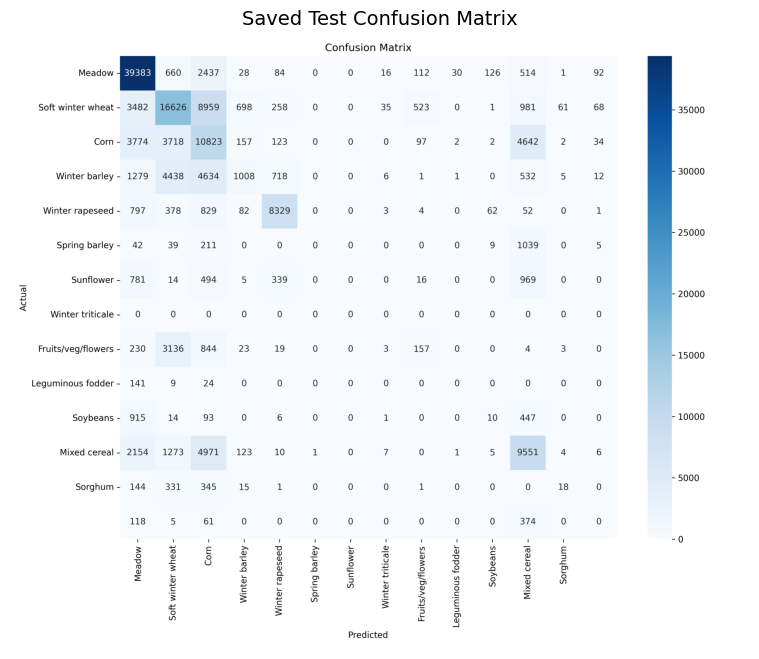

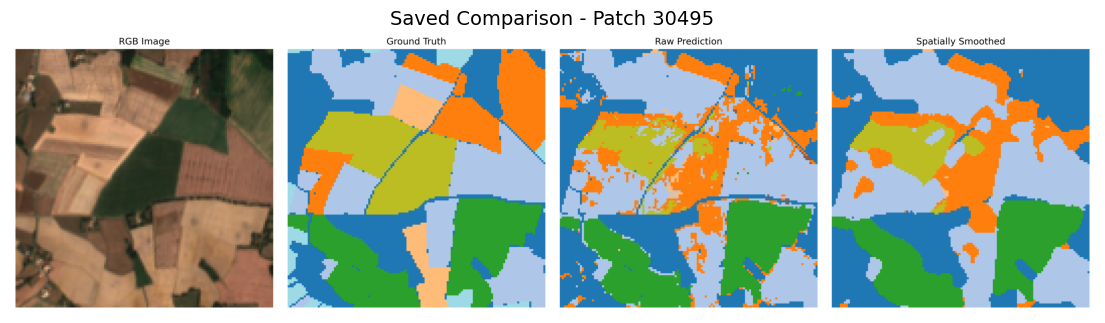

In [24]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig_dir = os.path.join('..', 'outputs', 'figures')
cm_path = os.path.join(fig_dir, 'test_confusion_matrix.png')
patch_path = os.path.join(fig_dir, f'test_patch_{test_patch_id}_comparison.png')

# Display Confusion Matrix
if os.path.exists(cm_path):
    plt.figure(figsize=(10, 8))
    plt.imshow(mpimg.imread(cm_path))
    plt.axis('off')
    plt.title("Saved Test Confusion Matrix", fontsize=14)
    plt.show()
else:
    print(f"File not found: {cm_path}")

# Display Test Patch Prediction Comparison
if os.path.exists(patch_path):
    plt.figure(figsize=(14, 8))
    plt.imshow(mpimg.imread(patch_path))
    plt.axis('off')
    plt.title(f"Saved Comparison - Patch {test_patch_id}", fontsize=14)
    plt.show()
else:
    print(f"File not found: {patch_path}")

# G Analysis & interpretation

In [ ]:
# check report_v1.md